# Imports

In [31]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import SparseLinear
from DenseMLP import DenseMLP
from SparseMLP import SparseMLP


# Loading Datasets

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256
)

# Evaluation Functions

In [3]:
def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in test_loader:

            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            preds = logits.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

# Train Function

In [34]:
def train_model(model, epochs=5, lr=1e-4):
    accuracies = []

    model = model.to(device)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.1,
        momentum=0.9
    )

    criterion = nn.CrossEntropyLoss()

    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for x, y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits = model(x)

            loss = criterion(logits, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            total_loss += loss.item()

        acc = evaluate(model)
        accuracies.append(acc)

        print(
            f"Epoch {epoch+1} | "
            f"Loss: {total_loss / len(train_loader):.4f} | "
            f"Accuracy: {acc:.4f}"
        )

    total_time = time.time() - start_time

    return accuracies, total_time

# Train Dense Model

In [35]:
dense_model = DenseMLP()

print("\nDense Training")
dense_acc, dense_time = train_model(
    dense_model,
    epochs=5
)

print("\nDense Results")
print("Final Accuracy:", dense_acc[-1])
print("Time:", dense_time)


Dense Training
Epoch 1 | Loss: 0.3348 | Accuracy: 0.9565
Epoch 2 | Loss: 0.1059 | Accuracy: 0.9661
Epoch 3 | Loss: 0.0728 | Accuracy: 0.9762
Epoch 4 | Loss: 0.0540 | Accuracy: 0.9751
Epoch 5 | Loss: 0.0412 | Accuracy: 0.9775

Dense Results
Final Accuracy: 0.9775
Time: 6.628570079803467


# Train Sparse Model

In [37]:
list_of_keep_ratios = [1, .99, .98, .95, .9, .89, .85, .8, .79, .75, .7, .69, .65, .6, .59, .55, .5, .49, .45, .4, .39, .35, .3, .29, .25, .2, .19, .15, .1]
list_of_list_of_sparse_accuracies = []
list_of_sparse_times = []

for keep_ratio in list_of_keep_ratios:
    
    sparse_model = SparseMLP(
        keep_ratio=keep_ratio
    )

    print(f"\nSparse Training: {keep_ratio*100:.0f}% Keep Ratio")

    sparse_acc, sparse_time = train_model(
        sparse_model,
        epochs=5
    )

    list_of_list_of_sparse_accuracies.append(sparse_acc)
    list_of_sparse_times.append(sparse_time)

    print(f"\nSparse Results: {keep_ratio*100:.0f}% Keep Ratio")
    print("Final Accuracy:", sparse_acc[-1])
    print("Time:", sparse_time)


Sparse Training: 100% Keep Ratio
Epoch 1 | Loss: 0.2607 | Accuracy: 0.9533
Epoch 2 | Loss: 0.0982 | Accuracy: 0.9724
Epoch 3 | Loss: 0.0644 | Accuracy: 0.9759
Epoch 4 | Loss: 0.0497 | Accuracy: 0.9763
Epoch 5 | Loss: 0.0381 | Accuracy: 0.9727

Sparse Results: 100% Keep Ratio
Final Accuracy: 0.9727
Time: 7.679125785827637

Sparse Training: 99% Keep Ratio
Epoch 1 | Loss: 0.2719 | Accuracy: 0.9659
Epoch 2 | Loss: 0.0973 | Accuracy: 0.9651
Epoch 3 | Loss: 0.0718 | Accuracy: 0.9706
Epoch 4 | Loss: 0.0513 | Accuracy: 0.9745
Epoch 5 | Loss: 0.0396 | Accuracy: 0.9747

Sparse Results: 99% Keep Ratio
Final Accuracy: 0.9747
Time: 7.768244028091431

Sparse Training: 98% Keep Ratio
Epoch 1 | Loss: 0.2722 | Accuracy: 0.9648
Epoch 2 | Loss: 0.1016 | Accuracy: 0.9734
Epoch 3 | Loss: 0.0703 | Accuracy: 0.9750
Epoch 4 | Loss: 0.0529 | Accuracy: 0.9750
Epoch 5 | Loss: 0.0387 | Accuracy: 0.9788

Sparse Results: 98% Keep Ratio
Final Accuracy: 0.9788
Time: 8.008615970611572

Sparse Training: 95% Keep Ratio

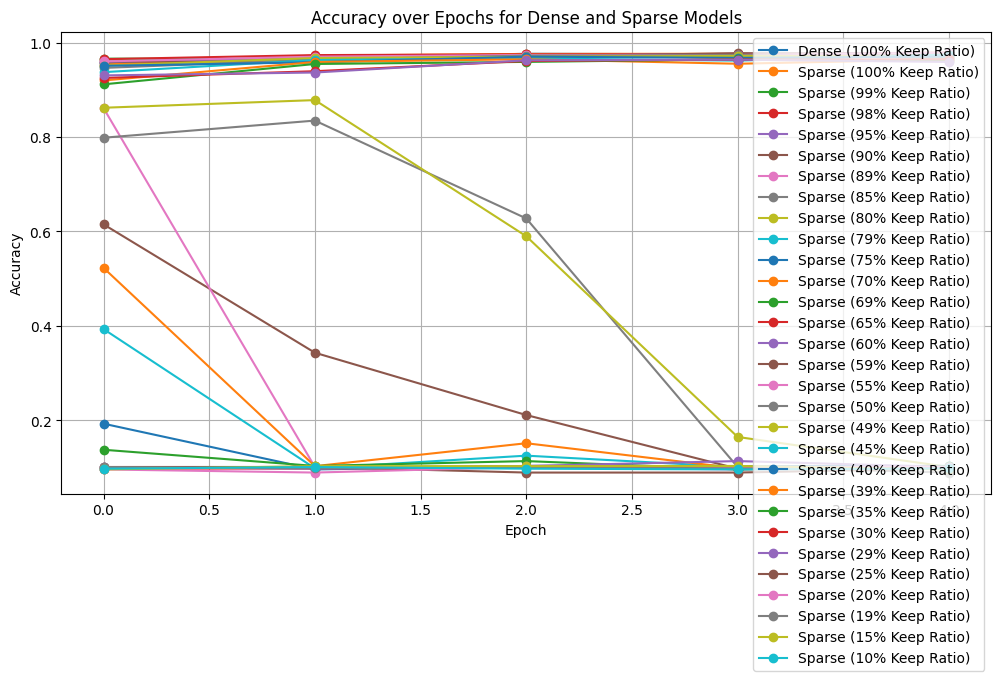

In [ ]:
# Plot Graph of full dense ratio and sparse ratios accuracies over epochs
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(dense_acc, label="Dense (100% Keep Ratio)", marker='o')
for keep_ratio, sparse_acc in zip(list_of_keep_ratios, list_of_list_of_sparse_accuracies):
    plt.plot(sparse_acc, label=f"Sparse ({keep_ratio*100:.0f}% Keep Ratio)", marker='o')
plt.title("Accuracy over Epochs for Dense and Sparse Models")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


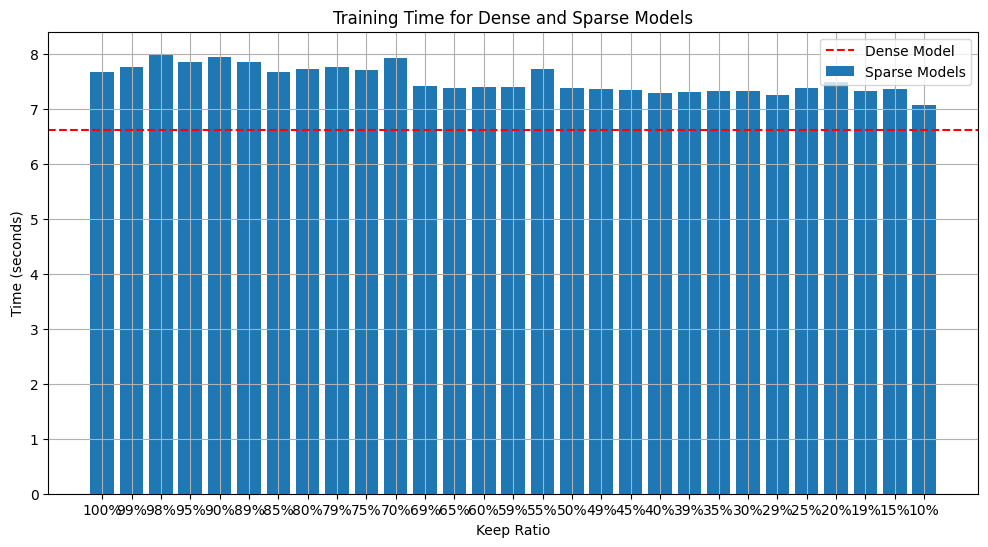

In [ ]:
# plot trainging time for each sparse model and the dense model as a horizontal line
plt.figure(figsize=(12, 6))
plt.bar(
    [f"{keep_ratio*100:.0f}%" for keep_ratio in list_of_keep_ratios],
    list_of_sparse_times,
    label="Sparse Models"
)
plt.axhline(y=dense_time, color='r', linestyle='--', label="Dense Model")
plt.title("Training Time for Dense and Sparse Models")
plt.xlabel("Keep Ratio")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid()
plt.show()

In [43]:
# give me a table for the training times of the dense model and the sparse models
import pandas as pd
data = {
    "Keep Ratio": [f"{keep_ratio*100:.0f}%" for keep_ratio in list_of_keep_ratios] + ["Dense (100%)"],
    "Training Time (seconds)": list_of_sparse_times + [dense_time]
}
df = pd.DataFrame(data)
print(df)


      Keep Ratio  Training Time (seconds)
0           100%                 7.679126
1            99%                 7.768244
2            98%                 8.008616
3            95%                 7.849837
4            90%                 7.945761
5            89%                 7.854334
6            85%                 7.673707
7            80%                 7.731491
8            79%                 7.772656
9            75%                 7.716481
10           70%                 7.934593
11           69%                 7.423036
12           65%                 7.377904
13           60%                 7.409230
14           59%                 7.406404
15           55%                 7.738618
16           50%                 7.381478
17           49%                 7.362772
18           45%                 7.347960
19           40%                 7.300890
20           39%                 7.306258
21           35%                 7.338317
22           30%                 7